In [1]:
from RNAFoldAssess.models.scorers import EternaScorer

In [2]:
import data_utils as du

def detect_dataset(line):
    ds = line[0]
    if ds == "RNAndria":
        if line[2].startswith("hsa"):
            return "RNAndria miRNA"
        else:
            return "RNAndria mRNA"
    else:
        return ds

with open("data/chemical_mapping_master_file.txt") as fh:
    dsci_data = fh.readlines()

dsci_data = [d.split(", ") for d in dsci_data]


dsci_data[0]

['EternaData',
 'ContextFold',
 'ETOBCR_VN1_0001_ANNOTATION_1',
 'GGUGGUAUUCUAAGCGAUGGUGAAACUACUAUUGGGCUUUCUACUCUUAGAUGGUCGUGUUGAUUGCAAUCAACACCUUAGAGUAAAAGAAACAACAACAACAAC',
 '.((.....((((((.(..((.....(((....))).....)).).)))))).....(((((((......)))))))........................))...',
 '0.5743243243243243\n']

In [3]:
unique_dps = list(set([line[2] for line in dsci_data]))

In [4]:
import csv

base_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data"
eterna_path = f"{base_path}/eterna_score_by_model_eterna_data.csv"
rnandria_human_path = f"{base_path}/eterna_score_by_model_rnandria_data.csv"
rnandria_pri_path = f"{base_path}/eterna_score_by_model_rnandria_pri_data.csv"
ribo_path = f"{base_path}/eterna_score_by_model_ribo_data.csv"

score_paths = [eterna_path, rnandria_human_path, rnandria_pri_path, ribo_path]

dp_model_map = {}
for p in score_paths:
    with open(p) as fh:
        eterna_score_data = csv.DictReader(fh)

        for row in eterna_score_data:
            dp = row["datapoint"]
            dp_model_map[dp] = {"dataset": None}
            for m in du.models:
                eterna_score = row[m]
                eterna_score = float(eterna_score)
                dp_model_map[dp][m] = {"eterna_score": eterna_score}

    for line in dsci_data:
        ds = detect_dataset(line)
        if ds == "YesselmanLab":
            continue
        model = line[1]
        dp = line[2]
        if dp not in dp_model_map:
            continue
        stc = line[4]
        dsci_score = float(line[5].strip())
        dp_model_map[dp]["dataset"] = ds
        dp_model_map[dp][model]["dsci_score"] = dsci_score


In [5]:
print(dp_model_map["ETOBCR_VN1_0001_ANNOTATION_1"])
print()
print(len(dp_model_map))

{'dataset': 'EternaData', 'ContextFold': {'eterna_score': 0.5396825396825397, 'dsci_score': 0.5743243243243243}, 'ContraFold': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'EternaFold': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'IPKnot': {'eterna_score': 0.5238095238095238, 'dsci_score': 0.4852941176470588}, 'MXFold': {'eterna_score': 0.746031746031746, 'dsci_score': 0.5606617647058824}, 'MXFold2': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'NeuralFold': {'eterna_score': 0.4444444444444444, 'dsci_score': 0.5564516129032258}, 'NUPACK': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'pKnots': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'RNAFold': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'RNAStructure': {'eterna_score': 0.7777777777777778, 'dsci_score': 0.5788409703504043}, 'Simfold': {'eterna_score': 0.7777777777777778, 

In [6]:
model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

def has_all_scores(datapoint_results):
    for model in model_order:
        if model not in datapoint_results:
            return False

        model_scores = datapoint_results[model]

        for score in ["eterna_score", "dsci_score"]:
            if score not in model_scores:
                return False

            if model_scores[score] is None:
                return False

    return True

In [7]:
fstring = "datapoint,dataset,model,eterna_score,dsci_score\n"

for datapoint_id, datapoint_results in dp_model_map.items():
    if not has_all_scores(datapoint_results):
        continue

    dataset = datapoint_results["dataset"]
    for m in model_order:
        line = f"{datapoint_id},{dataset},{m},"
        eterna_score = str(datapoint_results[m]["eterna_score"])
        dsci_score = str(datapoint_results[m]["dsci_score"])
        line += f"{eterna_score},{dsci_score}\n"
        fstring += line

    fstring.strip() # Remove last newline character

with open("data/chem_mapping_eterna_vs_dsci_scores.csv", "w") as fh:
    fh.write(fstring)


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_1045/1167926991.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/erikwhiting/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


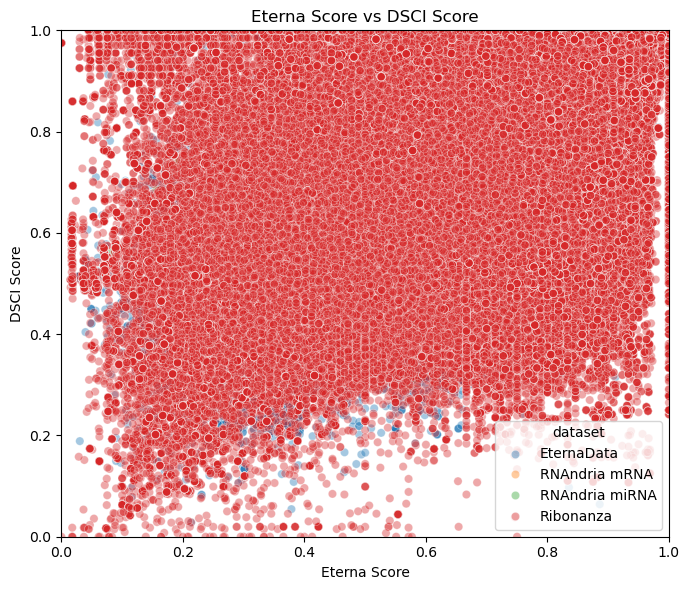

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df,
    x="eterna_score",
    y="dsci_score",
    hue="dataset",
    alpha=0.4
)

plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title("Eterna Score vs DSCI Score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [16]:
# Pearson correlation:
print("Overall correlation")
overall_corr = df[["eterna_score", "dsci_score"]].corr(method="spearman")
print(overall_corr)

print("Pearson correlation by dataset")
dataset_corr = (
    df.groupby("dataset")
      .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))
      .reset_index(name="pearson_corr")
)

print(dataset_corr)

print("Pearson correlation by model")
model_corr = (
    df.groupby("model")
      .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))
      .reset_index(name="pearson_corr")
)

print(model_corr)

Overall correlation
              eterna_score  dsci_score
eterna_score      1.000000    0.641284
dsci_score        0.641284    1.000000
Pearson correlation by dataset
          dataset  pearson_corr
0      EternaData      0.650763
1   RNAndria mRNA      0.394901
2  RNAndria miRNA      0.386189
3       Ribonanza      0.601621
Pearson correlation by model


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_1045/4042970662.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))


           model  pearson_corr
0    ContextFold      0.620050
1     ContraFold      0.612613
2     EternaFold      0.611620
3         IPKnot      0.575199
4         MXFold      0.631607
5        MXFold2      0.606292
6         NUPACK      0.596193
7     NeuralFold      0.627792
8        RNAFold      0.626416
9   RNAStructure      0.625627
10      SPOT-RNA      0.577961
11       Simfold      0.603448
12        pKnots      0.651033


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_1045/4042970662.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))


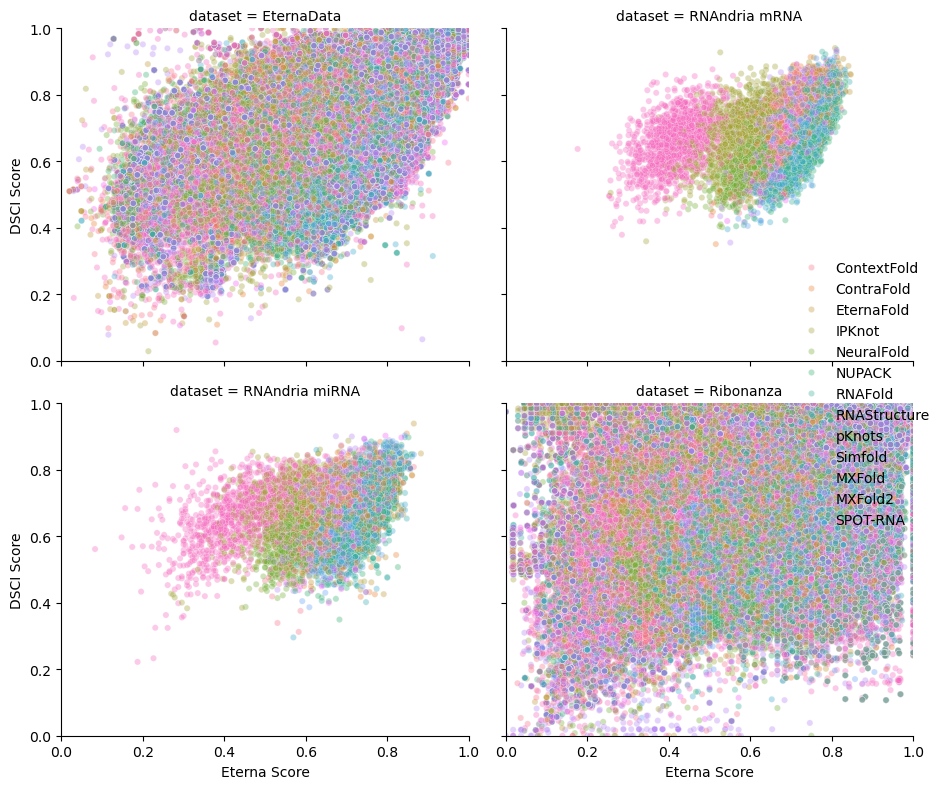

In [17]:
g = sns.FacetGrid(
    df,
    col="dataset",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="eterna_score",
    y="dsci_score",
    hue="model",
    alpha=0.35,
    s=20
)

g.set_axis_labels("Eterna Score", "DSCI Score")
g.set(xlim=(0, 1), ylim=(0, 1))
g.add_legend()

plt.tight_layout()
plt.show()

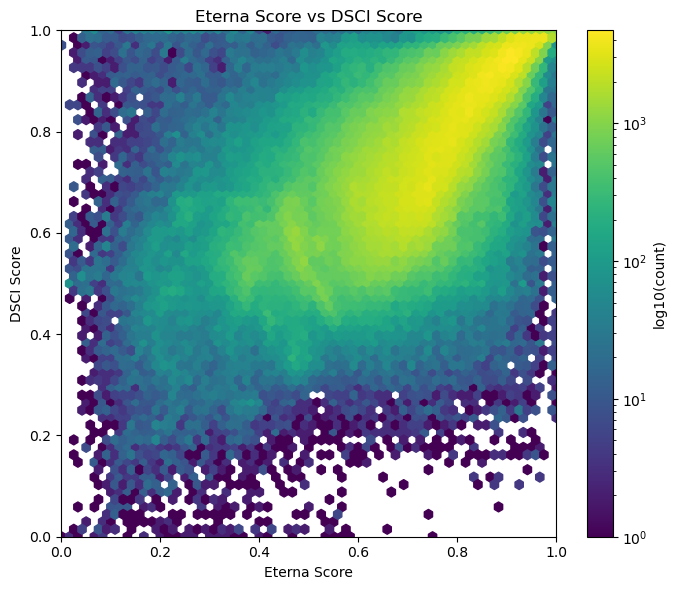

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")

plt.figure(figsize=(7, 6))

plt.hexbin(
    df["eterna_score"],
    df["dsci_score"],
    gridsize=60,
    extent=(0, 1, 0, 1),
    mincnt=1,
    bins="log"
)

plt.colorbar(label="log10(count)")
plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title("Eterna Score vs DSCI Score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

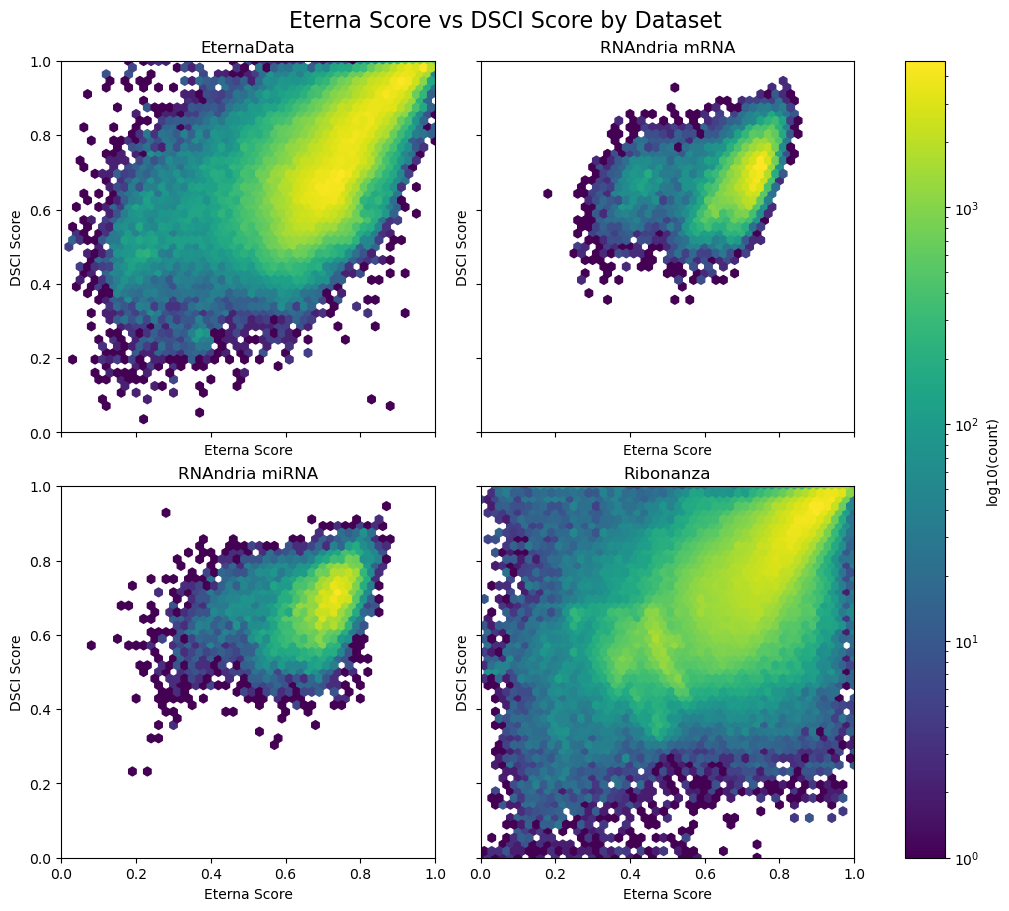

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")

datasets = sorted(df["dataset"].unique())

n_cols = 2
n_rows = math.ceil(len(datasets) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]

    hb = ax.hexbin(
        sub["eterna_score"],
        sub["dsci_score"],
        gridsize=50,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log"
    )

    ax.set_title(dataset)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Eterna Score")
    ax.set_ylabel("DSCI Score")

for ax in axes[len(datasets):]:
    ax.set_visible(False)

fig.colorbar(hb, ax=axes.tolist(), label="log10(count)", location="right")
fig.suptitle("Eterna Score vs DSCI Score by Dataset", fontsize=16)

# plt.tight_layout()
plt.show()

In [2]:
model_corr = (
    df.groupby("model")
      .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))
      .reset_index(name="pearson_corr")
)

print(model_corr)

           model  pearson_corr
0    ContextFold      0.620050
1     ContraFold      0.612613
2     EternaFold      0.611620
3         IPKnot      0.575199
4         MXFold      0.631607
5        MXFold2      0.606292
6         NUPACK      0.596193
7     NeuralFold      0.627792
8        RNAFold      0.626416
9   RNAStructure      0.625627
10      SPOT-RNA      0.577961
11       Simfold      0.603448
12        pKnots      0.651033


/var/folders/1f/c4zwfcn929qgw6shcb4frpjm0000gn/T/ipykernel_80001/1218963180.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["eterna_score"].corr(g["dsci_score"]))


In [22]:
ydata_path = "/Users/erikwhiting/src/RNAFoldAssess/data/all_data/chem_map_data_with_predictions/with_eterna_scores"

import json, os

# Make ydata CSV
files = os.listdir(ydata_path)
for f in files:
    fstring = "datapoint,dataset,model,eterna_score,dsci_score\n"
    cohort = f.split("_")[0]
    print(f"Working {cohort}")
    with open(f"{ydata_path}/{f}") as fh:
        ydata = json.load(fh)
    for d in ydata:
        dpname = d["name"]
        name = f"{cohort}_{dpname}"
        pred_data = d["predictions"]
        for model in pred_data:
            dsci_score = str(pred_data[model]["dsci_score"]["accuracy"])
            eterna_score = str(pred_data[model]["eterna_score"])
            line = f"{name},YesselmanLab,{model},{eterna_score},{dsci_score}\n"
            fstring += line

    print("Writing file")
    with open(f"data/{cohort}_ydata_eterna_vs_dsci_scores.csv", "w") as fh:
        fh.write(fstring)



Working C014U
Writing file
Working C014H
Writing file
Working C014J
Writing file
Working C014G
Writing file
Working C014V
Writing file
Working C014I
Writing file


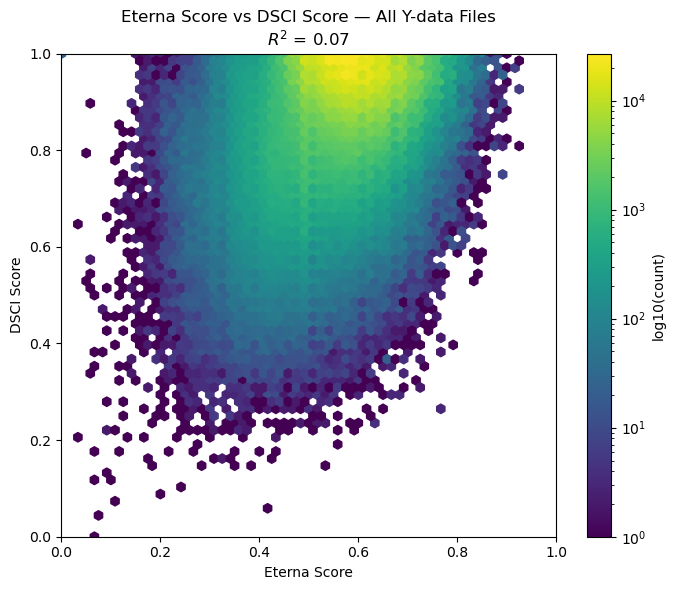

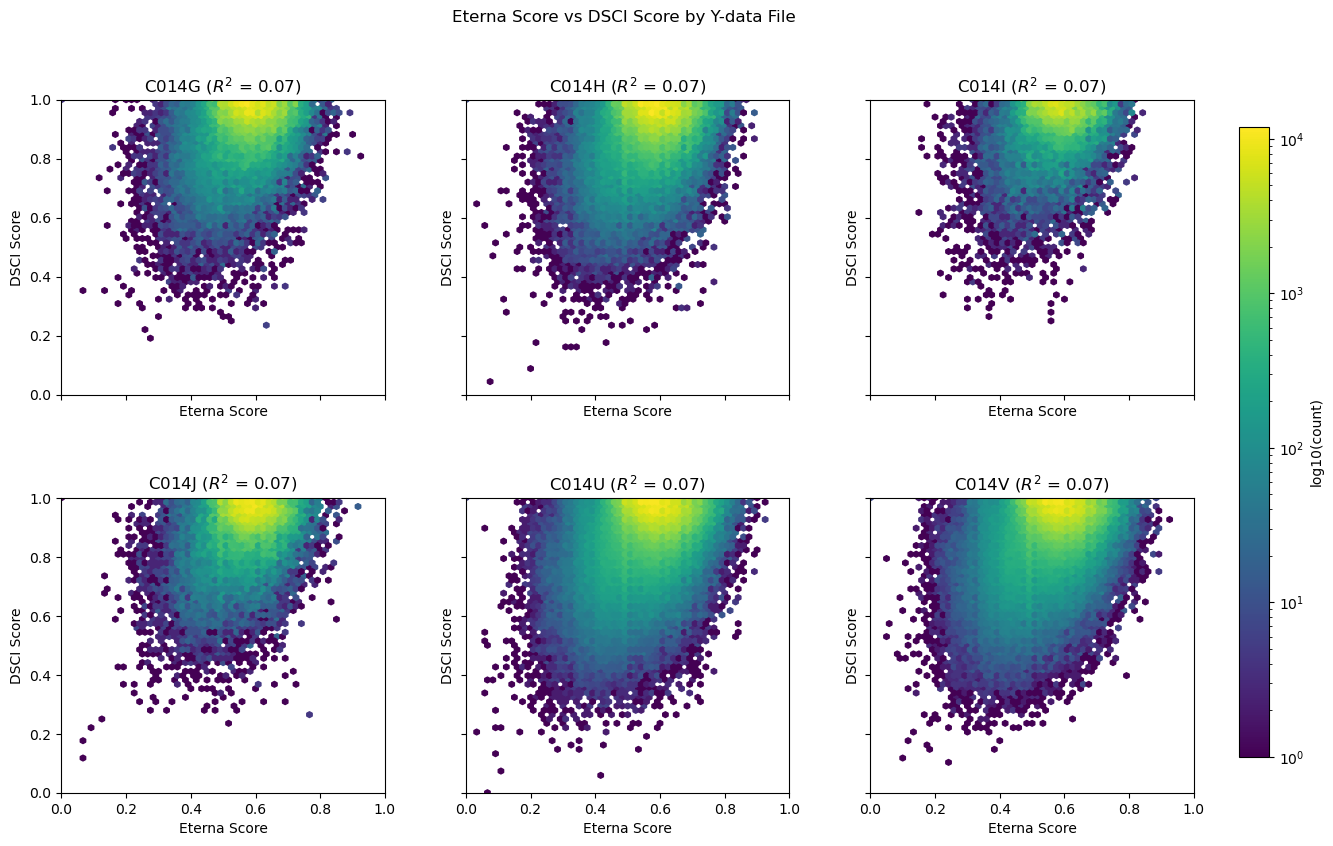

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

data_dir = Path("data")

files = [
    "C014G_ydata_eterna_vs_dsci_scores.csv",
    "C014H_ydata_eterna_vs_dsci_scores.csv",
    "C014I_ydata_eterna_vs_dsci_scores.csv",
    "C014J_ydata_eterna_vs_dsci_scores.csv",
    "C014U_ydata_eterna_vs_dsci_scores.csv",
    "C014V_ydata_eterna_vs_dsci_scores.csv",
]

# ---------------------------------------------------------------------
# Read all files and keep track of which file each row came from
# ---------------------------------------------------------------------
dfs = []

for filename in files:
    df = pd.read_csv(data_dir / filename)
    df["source_file"] = filename.replace("_ydata_eterna_vs_dsci_scores.csv", "")
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# ---------------------------------------------------------------------
# Calculate R² for all combined data
# ---------------------------------------------------------------------
combined_r = combined_df["eterna_score"].corr(
    combined_df["dsci_score"],
    method="pearson"
)

combined_r2 = combined_r ** 2

# ---------------------------------------------------------------------
# Figure 1: One hexbin plot using all data
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 6))

hb = plt.hexbin(
    combined_df["eterna_score"],
    combined_df["dsci_score"],
    gridsize=60,
    extent=(0, 1, 0, 1),
    mincnt=1,
    bins="log"
)

plt.colorbar(hb, label="log10(count)")
plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title(f"Eterna Score vs DSCI Score — All Y-data Files\n$R^2$ = {combined_r2:.2f}")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Figure 2: Separate subplot for each file
# ---------------------------------------------------------------------
n_cols = 3
n_rows = math.ceil(len(files) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False
)

axes = axes.flatten()

for ax, filename in zip(axes, files):
    label = filename.replace("_ydata_eterna_vs_dsci_scores.csv", "")
    sub = combined_df[combined_df["source_file"] == label]

    # Calculate Pearson R² for this file
    r = sub["eterna_score"].corr(
        sub["dsci_score"],
        method="pearson"
    )
    r2 = r ** 2

    hb = ax.hexbin(
        sub["eterna_score"],
        sub["dsci_score"],
        gridsize=60,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log"
    )

    ax.set_title(f"{label} ($R^2$ = {r2:.2f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Eterna Score")
    ax.set_ylabel("DSCI Score")

# Remove unused axes if any
for ax in axes[len(files):]:
    ax.remove()

# Reserve space for colorbar
fig.subplots_adjust(
    right=0.88,
    wspace=0.25,
    hspace=0.35
)

# Dedicated colorbar axis
cbar_ax = fig.add_axes([
    0.91,  # left position
    0.15,  # bottom position
    0.02,  # width
    0.70   # height
])

fig.colorbar(
    hb,
    cax=cbar_ax,
    label="log10(count)"
)

fig.suptitle("Eterna Score vs DSCI Score by Y-data File", y=0.98)

plt.show()

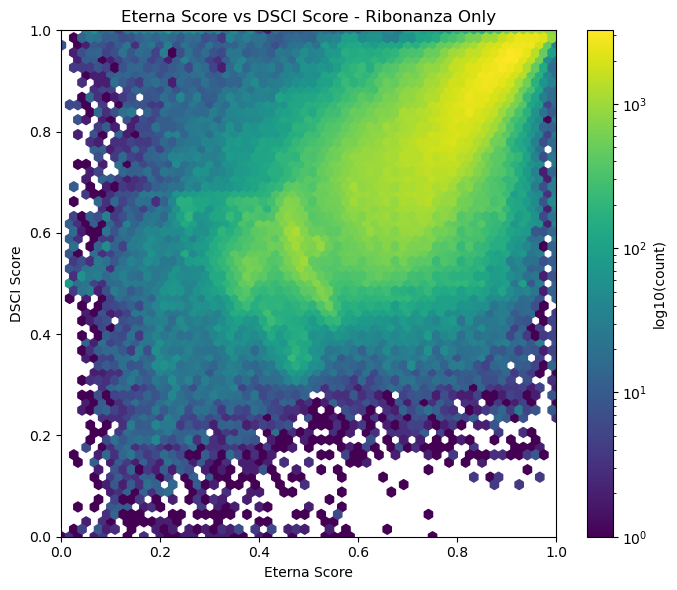

In [4]:
chem_map_df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")
ribo_df = chem_map_df[chem_map_df["dataset"] == "Ribonanza"]

plt.figure(figsize=(7, 6))

plt.hexbin(
    ribo_df["eterna_score"],
    ribo_df["dsci_score"],
    gridsize=60,
    extent=(0, 1, 0, 1),
    mincnt=1,
    bins="log"
)

plt.colorbar(label="log10(count)")
plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title("Eterna Score vs DSCI Score - Ribonanza Only")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import linregress

eterna_threshold = 0.5
dsci_threshold = 0.5

bottom_left_df = ribo_df[
    (ribo_df["eterna_score"] < eterna_threshold) &
    (ribo_df["dsci_score"] < dsci_threshold)
].copy()

full_result = linregress(
    ribo_df["eterna_score"],
    ribo_df["dsci_score"]
)

bottom_left_result = linregress(
    bottom_left_df["eterna_score"],
    bottom_left_df["dsci_score"]
)

full_r2 = full_result.rvalue ** 2
bottom_left_r2 = bottom_left_result.rvalue ** 2

print(f"Ribonanza full dataset R²: {full_r2:.4f}")
print(f"Bottom-left subset R²: {bottom_left_r2:.4f}")
print(f"Full Ribonanza n: {len(ribo_df)}")
print(f"Bottom-left subset n: {len(bottom_left_df)}")

Ribonanza full dataset R²: 0.3619
Bottom-left subset R²: 0.1418
Full Ribonanza n: 865878
Bottom-left subset n: 24961


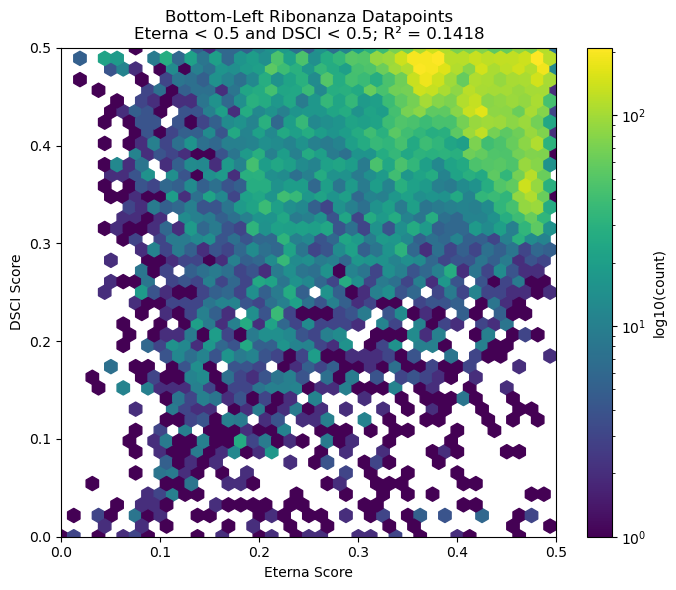

In [11]:
plt.figure(figsize=(7, 6))

hb = plt.hexbin(
    bottom_left_df["eterna_score"],
    bottom_left_df["dsci_score"],
    gridsize=40,
    extent=(0, 0.5, 0, 0.5),
    mincnt=1,
    bins="log"
)

plt.colorbar(hb, label="log10(count)")
plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title(
    f"Bottom-Left Ribonanza Datapoints\n"
    f"Eterna < 0.5 and DSCI < 0.5; R² = {bottom_left_r2:.4f}"
)

plt.xlim(0, 0.5)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.savefig("ribo_eterna_vs_dsci_bottom_left.png", dpi=500)
plt.show()

Ribonanza full dataset R²: 0.3619
Top-right subset R²: 0.3021
Full Ribonanza n: 865878
Top-right subset n: 721075


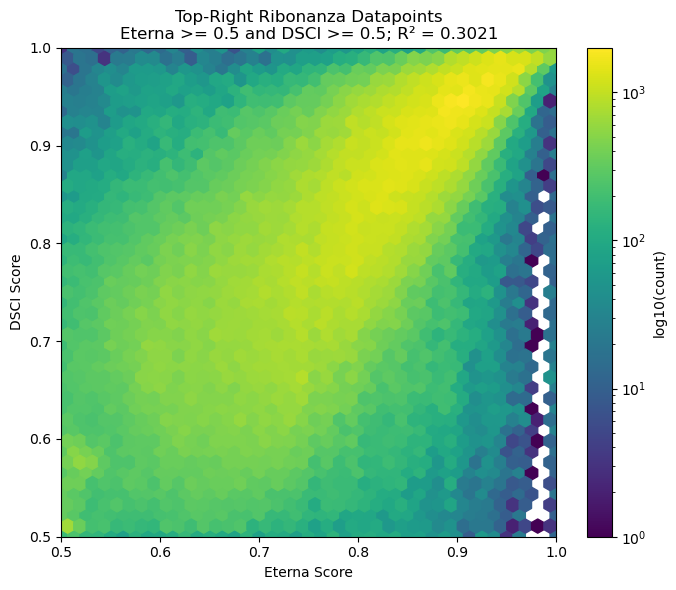

In [10]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

eterna_threshold = 0.5
dsci_threshold = 0.5

top_right_df = ribo_df[
    (ribo_df["eterna_score"] >= eterna_threshold) &
    (ribo_df["dsci_score"] >= dsci_threshold)
].copy()

full_result = linregress(
    ribo_df["eterna_score"],
    ribo_df["dsci_score"]
)

top_right_result = linregress(
    top_right_df["eterna_score"],
    top_right_df["dsci_score"]
)

full_r2 = full_result.rvalue ** 2
top_right_r2 = top_right_result.rvalue ** 2

print(f"Ribonanza full dataset R²: {full_r2:.4f}")
print(f"Top-right subset R²: {top_right_r2:.4f}")
print(f"Full Ribonanza n: {len(ribo_df)}")
print(f"Top-right subset n: {len(top_right_df)}")

plt.figure(figsize=(7, 6))

hb = plt.hexbin(
    top_right_df["eterna_score"],
    top_right_df["dsci_score"],
    gridsize=40,
    extent=(0.5, 1, 0.5, 1),
    mincnt=1,
    bins="log"
)

plt.colorbar(hb, label="log10(count)")
plt.xlabel("Eterna Score")
plt.ylabel("DSCI Score")
plt.title(
    f"Top-Right Ribonanza Datapoints\n"
    f"Eterna >= 0.5 and DSCI >= 0.5; R² = {top_right_r2:.4f}"
)

plt.xlim(0.5, 1)
plt.ylim(0.5, 1)
plt.tight_layout()
plt.savefig("ribo_eterna_vs_dsci_top_right.png", dpi=500)
plt.show()

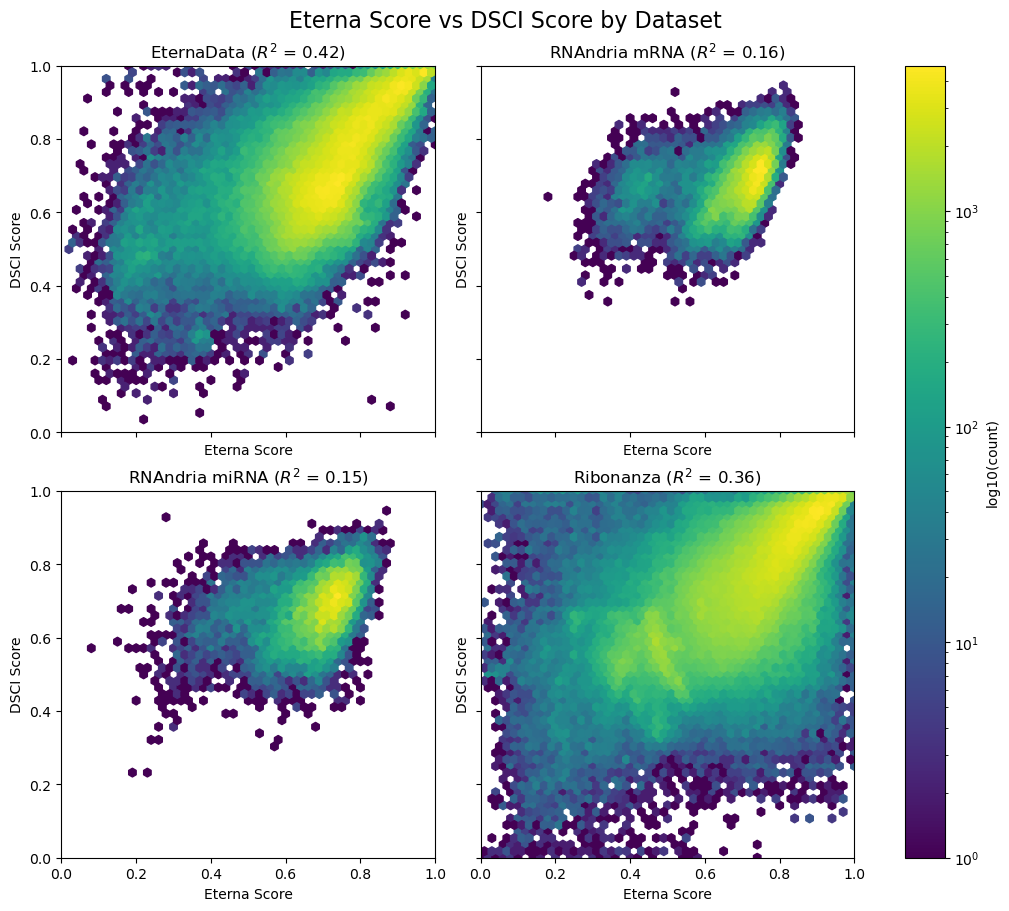

In [32]:
df = pd.read_csv("data/chem_mapping_eterna_vs_dsci_scores.csv")

datasets = sorted(df["dataset"].unique())

n_cols = 2
n_rows = math.ceil(len(datasets) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows),
    squeeze=False,
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    sub = df[df["dataset"] == dataset]

    # Pearson correlation squared
    r = sub["eterna_score"].corr(sub["dsci_score"], method="pearson")
    r2 = r ** 2

    hb = ax.hexbin(
        sub["eterna_score"],
        sub["dsci_score"],
        gridsize=50,
        extent=(0, 1, 0, 1),
        mincnt=1,
        bins="log"
    )

    ax.set_title(f"{dataset} ($R^2$ = {r2:.2f})")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Eterna Score")
    ax.set_ylabel("DSCI Score")

for ax in axes[len(datasets):]:
    ax.set_visible(False)

fig.colorbar(hb, ax=axes.tolist(), label="log10(count)", location="right")
fig.suptitle("Eterna Score vs DSCI Score by Dataset", fontsize=16)

plt.show()